Missing Values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment  
count  6435.000000   6435.000000  
mean    171.578394      7.999151  
std      39.35

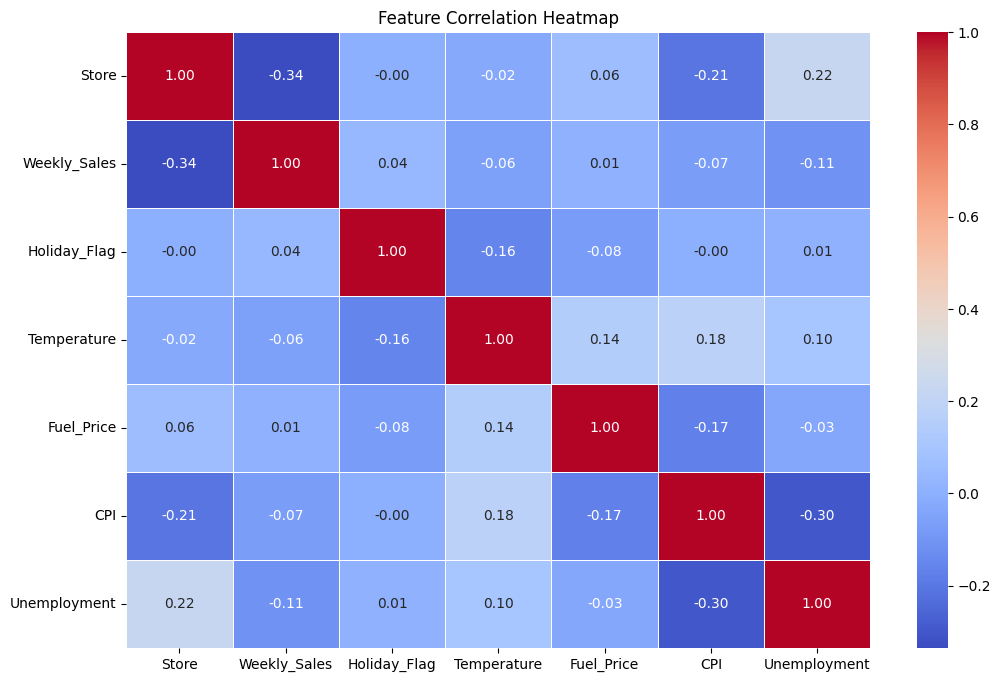

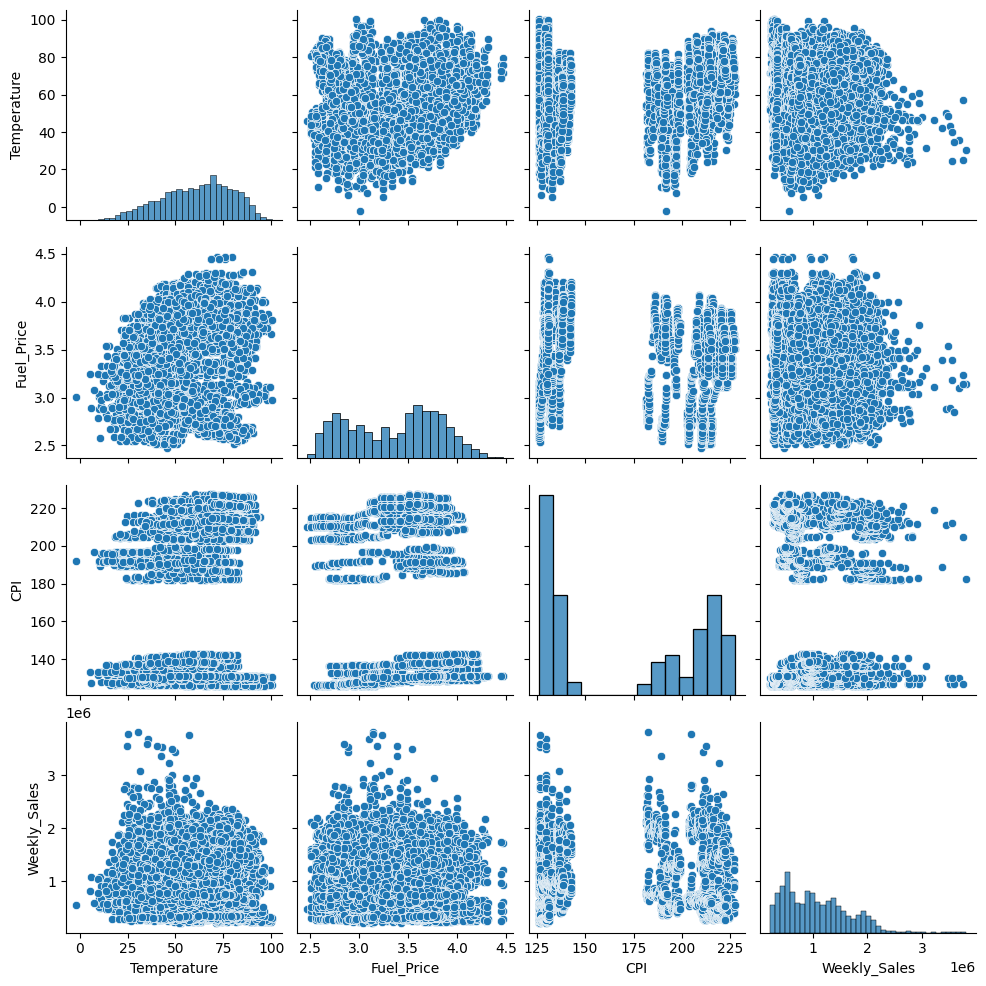

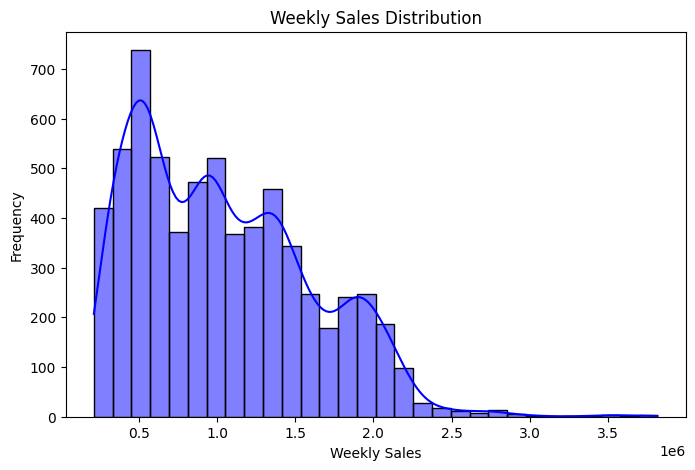

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:\n", df.describe())

# Correlation heatmap
plt.figure(figsize=(12, 8))
# Exclude non-numeric columns (like 'Date') from correlation calculation
sns.heatmap(df.drop('Date', axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

# Pairplot for key variables
sns.pairplot(df[['Temperature', 'Fuel_Price', 'CPI', 'Weekly_Sales']])
plt.show()

# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Weekly Sales Distribution")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales", "Date"])  # Drop 'Weekly_Sales' and 'Date' columns
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1481
RMSE: 523884.7405


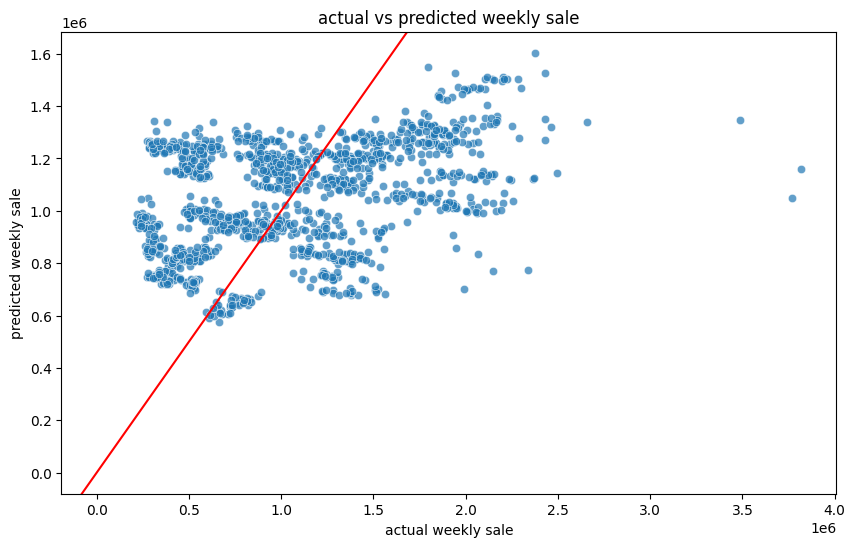

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("actual weekly sale")
plt.ylabel("predicted weekly sale")
plt.title("actual vs predicted weekly sale")

plt.axline([0,0],[1,1],color='red',linestyle='-')
plt.show()

In [9]:
from scipy.stats import skew

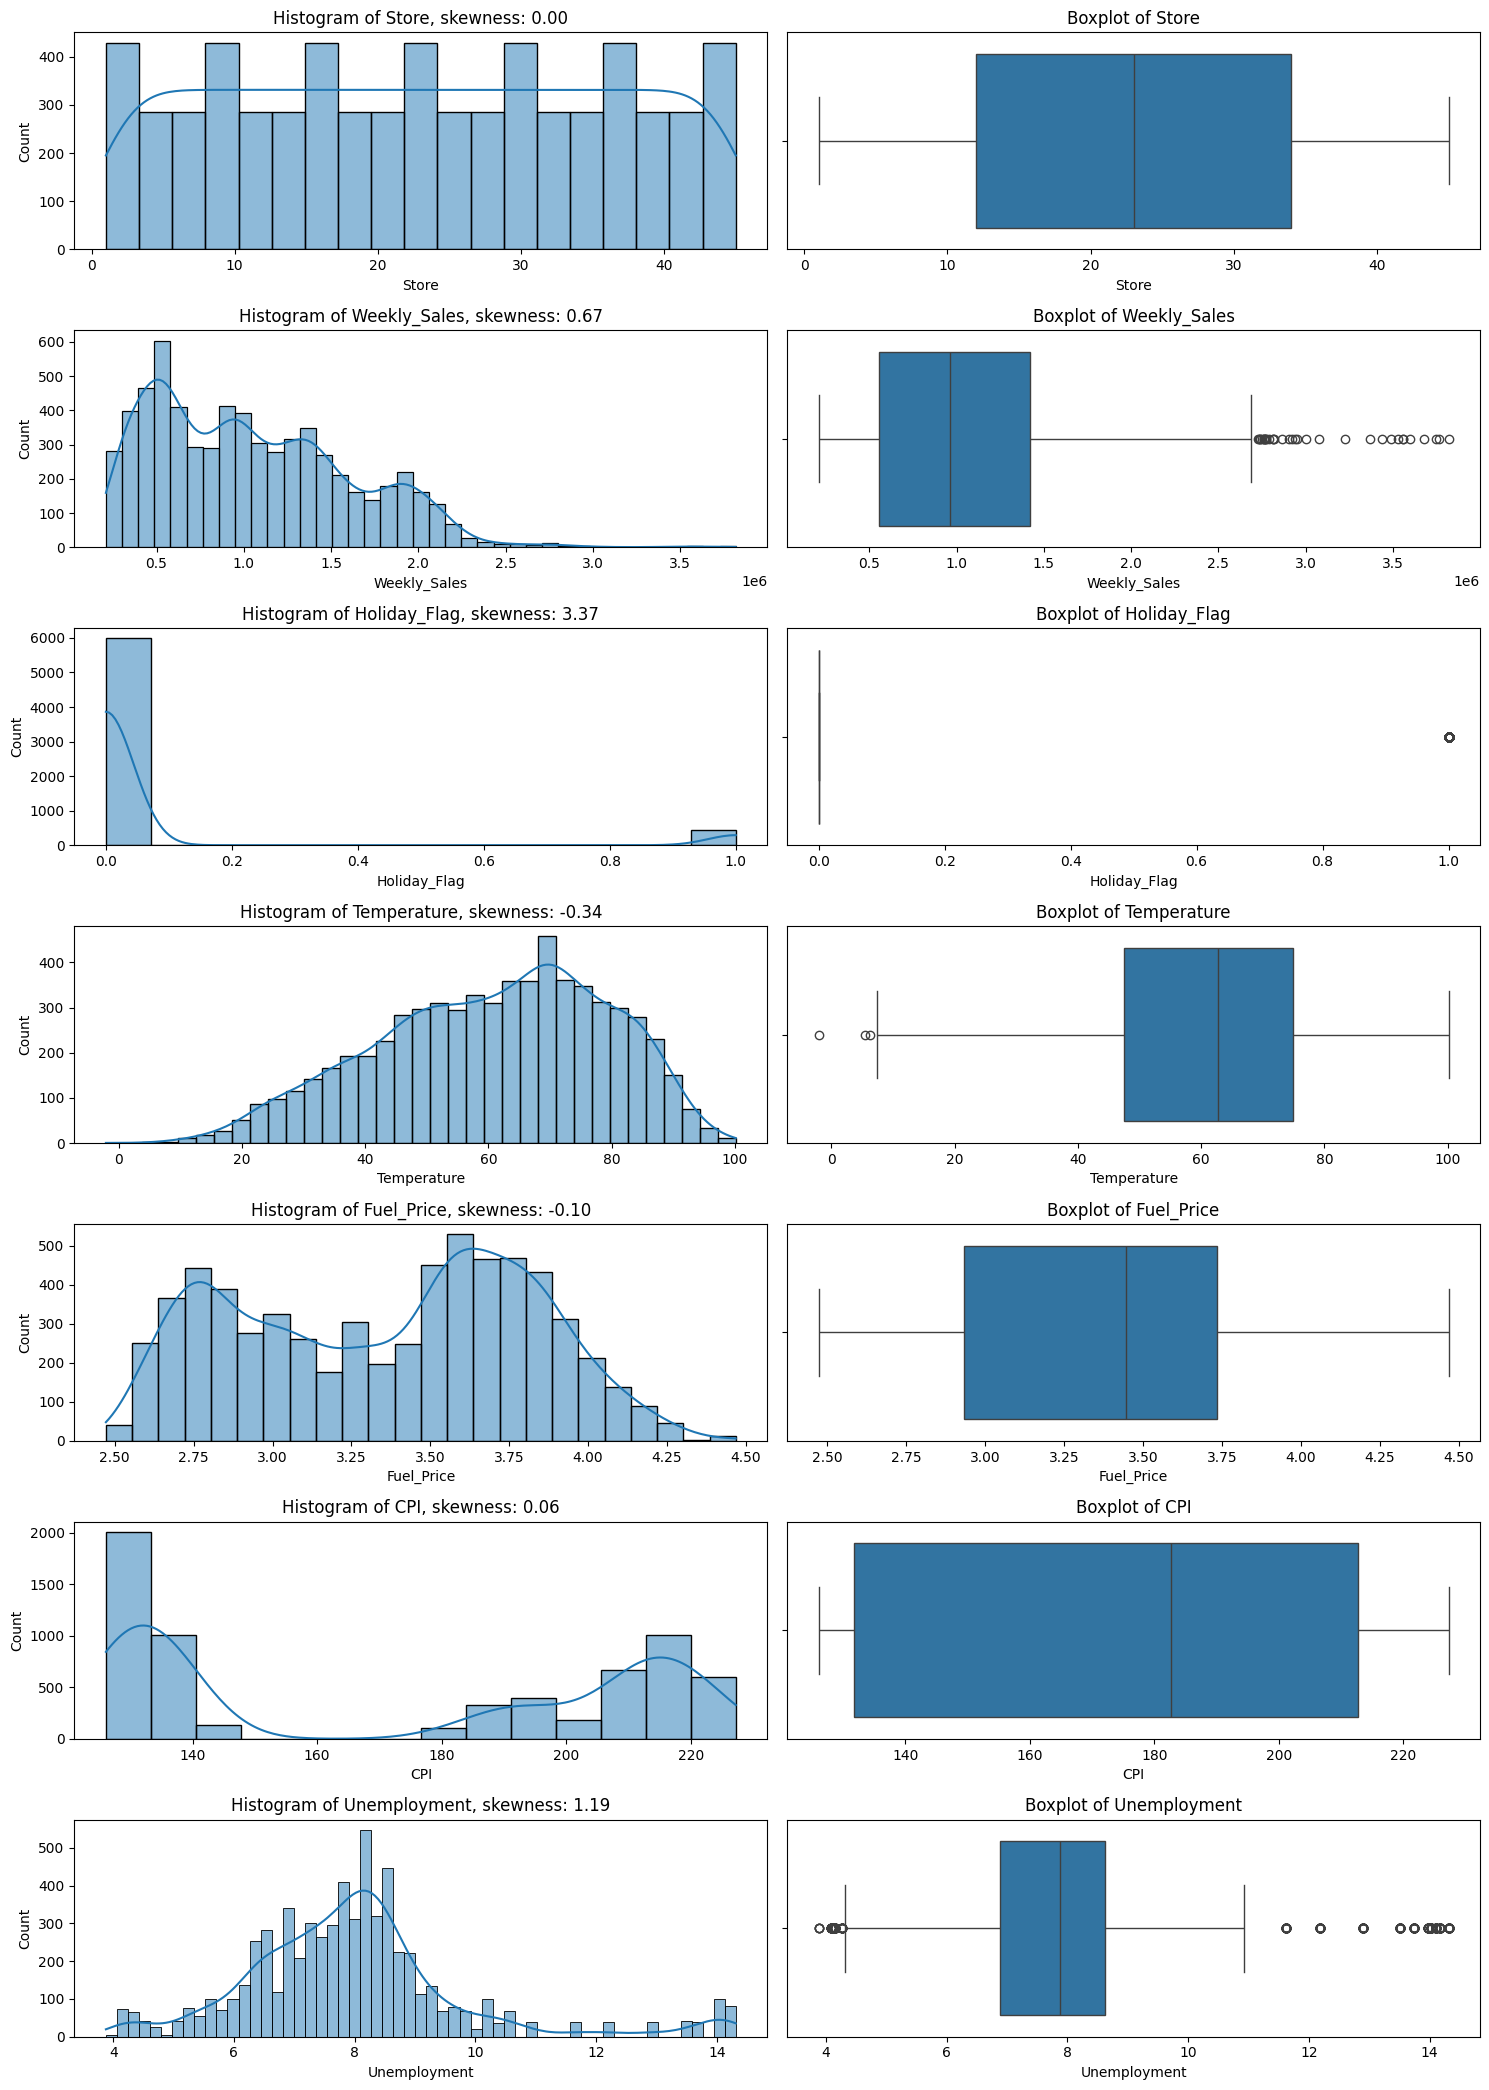

In [11]:
import numpy as np

# Select only numeric columns for skewness calculation and plotting
df_numeric = df.select_dtypes(include=np.number)
skewness = df_numeric.skew()

num_cols = len(df_numeric.columns)

plt.figure(figsize=(15, num_cols * 3))

for i, col in enumerate(df_numeric.columns):
  plt.subplot(num_cols, 2, 2 * i + 1)
  sns.histplot(df_numeric[col], kde=True)
  plt.title(f"Histogram of {col}, skewness: {skewness[col]:.2f}")

  plt.subplot(num_cols, 2, 2 * i + 2)
  sns.boxplot(x=df_numeric[col])
  plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [13]:
#find high skewed column
import numpy as np
# Reusing the skewness calculated from numerical columns in the previous cell
skewed_cols = skewness.abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("highly skewed columns:\n",highly_skewed)
print("negatively skewed columns:\n",negatively_skewed)

highly skewed columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
negatively skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI'], dtype='object')


In [14]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))


In [15]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])


In [17]:
import numpy as np
# Calculate skewness only for numerical columns in the updated DataFrame
df.select_dtypes(include=np.number).skew()

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.226991


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales", "Date"])  # All columns except target and 'Date'
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1270
RMSE: 0.9464


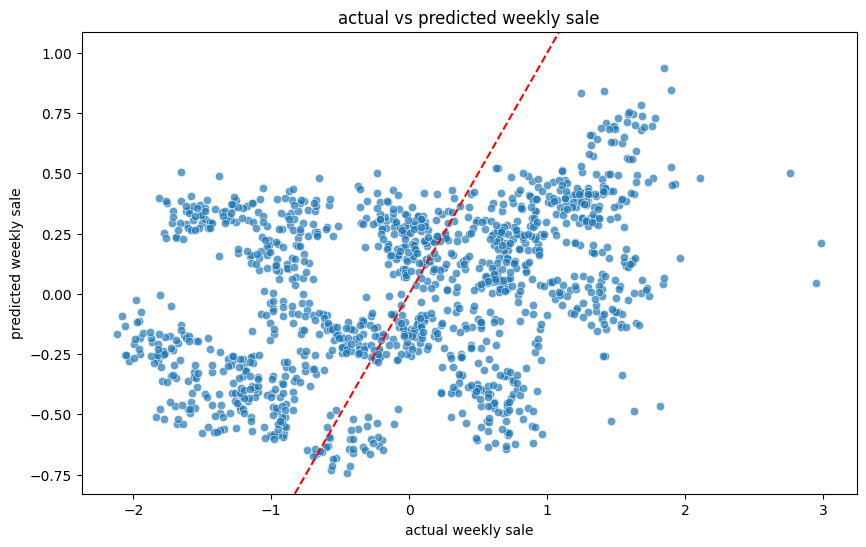

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel("actual weekly sale")
plt.ylabel("predicted weekly sale")
plt.title("actual vs predicted weekly sale")

plt.axline([0,0],[1,1],color='red',linestyle='--')
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor

#train random forest
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#prediction and evaluation
y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print(f"random forest R^2 score: {r2:.4f}")
print(f"random forest RMSE: {rmse:.4f}")

random forest R^2 score: 0.9619
random forest RMSE: 0.1976
